![Py4Eng](logo.png)

# Set Models
## Yoav Ram

This notebook compares three architectures for classifying **unordered sets** of items:
1. **Flattened FFN** — concatenate all items into one vector and process with feed forward network
2. **Deep Sets** — shared per-item feed-forward network with sum pooling
3. **Set Transformer** — self-attention over items with mean pooling

We use the [Poker Hand dataset](https://archive.ics.uci.edu/dataset/158/poker+hand) as a running example: each hand is a set of 5 cards, and the task is to classify the hand type (pair, flush, straight, etc.).

The main goal is to understand how **inductive biases** — particularly **permutation invariance** — affect learning on set-structured data, and to motivate the move to sequence models in later notebooks.

In [53]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import jax
import jax.numpy as jnp
import numpy as np
import optax

print('jax', jax.__version__, jax.default_backend())

key = jax.random.key(8765)

jax 0.9.2 cpu


## Problem Setup

A poker hand is a set of 5 cards. Each card has a **suit** (Hearts, Spades, Diamonds, Clubs) and a **rank** (Ace through King). The task is to classify the hand into one of 10 types:

| Class | Hand type       | Example             |
|-------|----------------|---------------------|
| 0     | Nothing         | 2♠ 5♦ 8♣ J♥ K♦     |
| 1     | One pair        | 3♠ 3♦ 7♣ J♥ K♦     |
| 2     | Two pairs       | 3♠ 3♦ 7♣ 7♥ K♦     |
| 3     | Three of a kind | 3♠ 3♦ 3♣ J♥ K♦     |
| 4     | Straight        | 5♠ 6♦ 7♣ 8♥ 9♦     |
| 5     | Flush           | 2♠ 5♠ 8♠ J♠ K♠     |
| 6     | Full house      | 3♠ 3♦ 3♣ 7♥ 7♦     |
| 7     | Four of a kind  | 3♠ 3♦ 3♣ 3♥ K♦     |
| 8     | Straight flush  | 5♠ 6♠ 7♠ 8♠ 9♠     |
| 9     | Royal flush     | 10♠ J♠ Q♠ K♠ A♠    |

This is a natural **set classification** problem: the order of cards in a hand does not matter — {3♠, 7♦, K♣, 2♥, 9♠} is the same hand regardless of how the cards are arranged.

## Data

The [Poker Hand dataset](https://archive.ics.uci.edu/dataset/158/poker+hand) from the UCI Machine Learning Repository contains over 1 million hands. Each hand is described by 10 attributes (suit and rank for each of 5 cards) and a class label.

In [54]:
import urllib.request

data_dir = 'data'
base_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/poker'
files = {
    'poker-hand-training-true.data': f'{base_url}/poker-hand-training-true.data',
    'poker-hand-testing.data': f'{base_url}/poker-hand-testing.data',
}

for fname, url in files.items():
    path = os.path.join(data_dir, fname)
    if not os.path.exists(path):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, path)
        print('Done.')

raw_train = np.loadtxt(os.path.join(data_dir, 'poker-hand-training-true.data'), delimiter=',', dtype=int)
raw_test = np.loadtxt(os.path.join(data_dir, 'poker-hand-testing.data'), delimiter=',', dtype=int)
raw = np.concatenate([raw_train, raw_test], axis=0)

print(f"Total hands: {len(raw):,}")
print(f"Columns: {raw.shape[1]} (5 cards × 2 attributes + 1 label)")

Total hands: 1,025,010
Columns: 11 (5 cards × 2 attributes + 1 label)


In [55]:
# Columns: S1, C1, S2, C2, S3, C3, S4, C4, S5, C5, CLASS
suits = raw[:, [0, 2, 4, 6, 8]] - 1    # (N, 5), values 0-3
ranks = raw[:, [1, 3, 5, 7, 9]] - 1    # (N, 5), values 0-12
labels = raw[:, 10]                      # (N,),   values 0-9

hand_names = [
    'Nothing', 'One pair', 'Two pairs', 'Three of a kind', 'Straight',
    'Flush', 'Full house', 'Four of a kind', 'Straight flush', 'Royal flush'
]
n_classes = len(hand_names)

print("Class distribution:")
for c in range(n_classes):
    count = (labels == c).sum()
    print(f"  {c}: {hand_names[c]:<20s} {count:>8,d} ({100 * count / len(labels):.2g}%)")

Class distribution:
  0: Nothing               513,702 (50%)
  1: One pair              433,097 (42%)
  2: Two pairs              48,828 (4.8%)
  3: Three of a kind        21,634 (2.1%)
  4: Straight                3,978 (0.39%)
  5: Flush                   2,050 (0.2%)
  6: Full house              1,460 (0.14%)
  7: Four of a kind            236 (0.023%)
  8: Straight flush             17 (0.0017%)
  9: Royal flush                 8 (0.00078%)


In [56]:
# Shuffle and split: 80% train, 10% val, 10% test
key, subkey = jax.random.split(key)
perm = jax.random.permutation(subkey, len(labels))  
suits, ranks, labels = suits[perm], ranks[perm], labels[perm]

n = len(labels)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_suits  = jnp.array(suits[:n_train])
train_ranks  = jnp.array(ranks[:n_train])
train_labels = jnp.array(labels[:n_train])

val_suits  = jnp.array(suits[n_train:n_train + n_val])
val_ranks  = jnp.array(ranks[n_train:n_train + n_val])
val_labels = jnp.array(labels[n_train:n_train + n_val])

test_suits  = jnp.array(suits[n_train + n_val:])
test_ranks  = jnp.array(ranks[n_train + n_val:])
test_labels = jnp.array(labels[n_train + n_val:])

print(f"Train: {len(train_labels):,}  Val: {len(val_labels):,}  Test: {len(test_labels):,}")

Train: 820,008  Val: 102,501  Test: 102,501


## Shared Utilities

All three models share the same card embedding, loss function, and training loop.

Each card is represented by learned embeddings for suit and rank, concatenated into a single vector:
$$\mathbf{e}_i = [\text{emb}_{\text{suit}}(s_i), \text{emb}_{\text{rank}}(r_i)]$$

In [57]:
# Card embedding dimensions
d_suit = 4
d_rank = 8
d_card = d_suit + d_rank  # 12
n_cards = 5


def embed_cards(params, suits, ranks):
    """
    suits : (B, 5) int, values 0-3
    ranks : (B, 5) int, values 0-12
    Returns: (B, 5, d_card) where d_card = d_suit + d_rank
    """
    s = params['suit_emb'][suits]   # (B, 5, d_suit)
    r = params['rank_emb'][ranks]   # (B, 5, d_rank)
    return jnp.concatenate([s, r], axis=-1)


def cross_entropy_loss(logits, targets):
    """
    logits : (B, n_classes) float32
    targets: (B,) int32
    """
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(log_probs[jnp.arange(targets.shape[0]), targets])


def count_params(pytree):
    leaves = jax.tree_util.tree_leaves(pytree)
    return sum(x.size for x in leaves if hasattr(x, 'size'))


def accuracy(params, forward_fn, suits, ranks, labels, batch_size=4096):
    """Compute accuracy in batches to avoid memory issues."""
    n = len(labels)
    correct = 0
    for i in range(0, n, batch_size):
        logits = forward_fn(params, suits[i:i + batch_size], ranks[i:i + batch_size])
        preds = jnp.argmax(logits, axis=-1)
        correct += jnp.sum(preds == labels[i:i + batch_size])
    return float(correct / n)

Train loop will be the same for all models: using cross entropy loss, AdamW optimizer, and batches.

In [58]:
def train(name, init_fn, forward_fn, key, n_steps=50000, batch_size=256, lr=1e-3):
    """Train a model and return params + training history."""
    key, subkey = jax.random.split(key)
    params = init_fn(subkey)
    n_p = count_params(params)
    print(f"{name}: {n_p:,} parameters")

    optimizer = optax.adamw(lr, weight_decay=1e-4)
    opt_state = optimizer.init(params)

    def loss_fn(p, s, r, y):
        return cross_entropy_loss(forward_fn(p, s, r), y)
    loss_grads = jax.value_and_grad(loss_fn)

    @jax.jit
    def step(params, opt_state, s, r, y):
        loss, grads = loss_grads(params, s, r, y)
        updates, opt_state_new = optimizer.update(grads, opt_state, params)
        params_new = optax.apply_updates(params, updates)
        return params_new, opt_state_new, loss

    train_losses = []
    val_log = []
    log_every = 1000
    n_train = len(train_labels)

    # Subsample validation for speed during training
    val_n = min(5000, len(val_labels))
    vs, vr, vy = val_suits[:val_n], val_ranks[:val_n], val_labels[:val_n]

    for i in range(1, n_steps + 1):
        key, subkey = jax.random.split(key)
        idx = jax.random.randint(subkey, (batch_size,), 0, n_train)
        params, opt_state, loss = step(
            params, opt_state, train_suits[idx], train_ranks[idx], train_labels[idx]
        )
        train_losses.append(float(loss))

        if i % log_every == 0:
            v_logits = forward_fn(params, vs, vr)
            v_loss = cross_entropy_loss(v_logits, vy)
            val_log.append((i, float(v_loss)))
            print(f"  step {i:5d} | train={train_losses[-1]:.4f} | val={float(v_loss):.4f}")

    return params, train_losses, val_log

In [59]:
def plot_training(name, train_losses, val_log):
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, alpha=0.3, label='train')
    if val_log:
        vs, vl = zip(*val_log)
        plt.plot(vs, vl, 'o-', label='val')
    plt.xlabel('Step')
    plt.ylabel('Cross-entropy loss')
    plt.ylim(0, 1.1)
    plt.title(name)
    plt.legend() 
    plt.tight_layout() 
    plt.show()

# Model 1: Flattened FFN

The simplest approach: flatten all 5 card embeddings into a single vector and pass it through a standard FFN.

$$\mathbf{x} = [\mathbf{e}_1 , \mathbf{e}_2, \mathbf{e}_3, \mathbf{e}_4, \mathbf{e}_5]$$
$$\mathbf{z_1} = \text{ReLU}(W_1 \mathbf{x} + b_1)$$
$$\mathbf{z_2} =\text{ReLU}(W_2 \cdot \mathbf{z_1} + b_2)$$
$$\hat{y} = \text{softmax}\big(W_3 \cdot \mathbf{z_2} + b_3\big)$$

This approach has two key limitations:
- **Fixed input size**: the model is hardcoded to exactly 5 cards. Adding a 6th card would require a new architecture.
- **Not permutation-invariant**: swapping two cards in the input changes the flattened vector and can change the output, even though the hand is the same. The model must learn to be approximately invariant from the data alone.

In [60]:
def init_params_ffn(key):
    d_hidden = 110
    keys = jax.random.split(key, 5)
    scale = 0.02
    return {
        'suit_emb': jax.random.normal(keys[0], (4, d_suit)) * scale,
        'rank_emb': jax.random.normal(keys[1], (13, d_rank)) * scale,
        'W1': jax.random.normal(keys[2], (n_cards * d_card, d_hidden)) * scale,
        'b1': jnp.zeros(d_hidden),
        'W2': jax.random.normal(keys[3], (d_hidden, d_hidden)) * scale,
        'b2': jnp.zeros(d_hidden),
        'W3': jax.random.normal(keys[4], (d_hidden, n_classes)) * scale,
        'b3': jnp.zeros(n_classes),
    }


def forward_ffn(params, suits, ranks):
    """suits, ranks: (B, 5) int -> logits: (B, n_classes)"""
    x = embed_cards(params, suits, ranks)     # (B, 5, d_card)
    x = x.reshape(x.shape[0], -1)             # (B, 5 * d_card)
    x = jax.nn.relu(x @ params['W1'] + params['b1'])
    x = jax.nn.relu(x @ params['W2'] + params['b2'])
    return x @ params['W3'] + params['b3']

In [61]:
%%time
subkey, key = jax.random.split(key)
ffn_params, ffn_losses, ffn_val = train('Flattened FFN', init_params_ffn, forward_ffn, subkey)

Flattened FFN: 20,150 parameters
  step  1000 | train=0.9303 | val=0.9910
  step  2000 | train=1.0212 | val=0.9899
  step  3000 | train=1.0613 | val=0.9923
  step  4000 | train=0.8996 | val=0.9905
  step  5000 | train=1.0235 | val=0.9916
  step  6000 | train=0.9614 | val=0.9911
  step  7000 | train=0.9616 | val=0.9905
  step  8000 | train=0.9437 | val=0.9607
  step  9000 | train=0.9827 | val=0.9265
  step 10000 | train=0.9286 | val=0.9174
  step 11000 | train=0.9260 | val=0.9094
  step 12000 | train=0.9222 | val=0.8703
  step 13000 | train=0.7875 | val=0.8468
  step 14000 | train=0.8722 | val=0.7667
  step 15000 | train=0.6820 | val=0.6959
  step 16000 | train=0.6108 | val=0.6412
  step 17000 | train=0.5606 | val=0.5881
  step 18000 | train=0.5179 | val=0.5628
  step 19000 | train=0.5631 | val=0.5273
  step 20000 | train=0.4123 | val=0.4666
  step 21000 | train=0.3413 | val=0.3960
  step 22000 | train=0.3969 | val=0.3430
  step 23000 | train=0.2467 | val=0.2906
  step 24000 | train=0.2

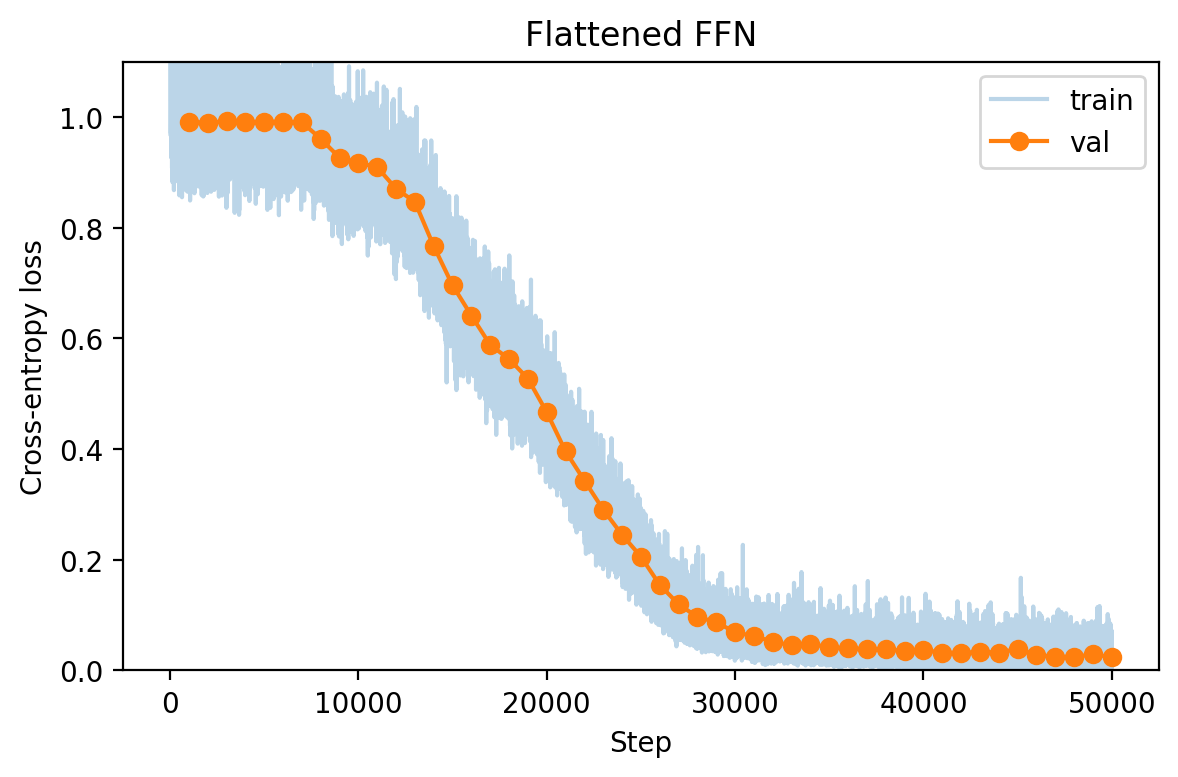

In [62]:
plot_training('Flattened FFN', ffn_losses, ffn_val)

### Permutation sensitivity

Since this model concatenates cards in a fixed order, permuting the cards changes the input vector and can change the prediction. We verify this empirically: take a batch of hands, randomly shuffle the card order, and check how many predictions change.

In [63]:
# Test permutation sensitivity on 1000 random hands
key, subkey = jax.random.split(key)
idx = jax.random.randint(subkey, (1000,), 0, len(test_labels))
s_orig, r_orig = test_suits[idx], test_ranks[idx]

# Random permutation of card order
key, subkey = jax.random.split(key)
perm = jax.random.permutation(subkey, 5)
s_perm, r_perm = s_orig[:, perm], r_orig[:, perm]

pred_orig = jnp.argmax(forward_ffn(ffn_params, s_orig, r_orig), axis=-1)
pred_perm = jnp.argmax(forward_ffn(ffn_params, s_perm, r_perm), axis=-1)
changed = float(jnp.mean(pred_orig != pred_perm))
print(f"FFN: {100 * changed:.2g}% of predictions changed after permuting card order")

FFN: 0.1% of predictions changed after permuting card order


# Model 2: Deep Sets

[Deep Sets](https://arxiv.org/abs/1703.06114) (Zaheer et al., 2017) gives the simplest architecture that is **permutation-invariant by construction**.

The idea: apply a shared network $\phi$ to each element independently, **sum** the results, then apply a second network $\rho$:

$$f(\{x_1, \ldots, x_n\}) = \rho\!\left(\sum_{i=1}^{n} \phi(x_i)\right)$$

Since addition is commutative, the output is the same regardless of the order of inputs.

For poker hands, this is a natural fit: the hand type depends on **counts** (how many cards share a rank or suit), and sum pooling naturally computes aggregate statistics over the cards.

**Why this works**: Zaheer et al. proved that any permutation-invariant function on a finite set can be decomposed into this $\rho(\sum \phi(x_i))$ form. So Deep Sets is not just a heuristic — it is a *universal approximator* for set functions.

In [64]:
def init_params_deepsets(key):
    d_hidden = 94
    keys = jax.random.split(key, 6)
    scale = 0.02
    return {
        'suit_emb': jax.random.normal(keys[0], (4, d_suit)) * scale,
        'rank_emb': jax.random.normal(keys[1], (13, d_rank)) * scale,
        # phi: shared per-card MLP
        'phi_W1': jax.random.normal(keys[2], (d_card, d_hidden)) * scale,
        'phi_b1': jnp.zeros(d_hidden),
        'phi_W2': jax.random.normal(keys[3], (d_hidden, d_hidden)) * scale,
        'phi_b2': jnp.zeros(d_hidden),
        # rho: post-pool classifier
        'rho_W1': jax.random.normal(keys[4], (d_hidden, d_hidden)) * scale,
        'rho_b1': jnp.zeros(d_hidden),
        'rho_W2': jax.random.normal(keys[5], (d_hidden, n_classes)) * scale,
        'rho_b2': jnp.zeros(n_classes),
    }


def forward_deepsets(params, suits, ranks):
    """suits, ranks: (B, 5) int -> logits: (B, n_classes)"""
    x = embed_cards(params, suits, ranks)                          # (B, 5, d_card)
    # phi: shared per-card MLP
    x = jax.nn.relu(x @ params['phi_W1'] + params['phi_b1'])      # (B, 5, d_hidden)
    x = jax.nn.relu(x @ params['phi_W2'] + params['phi_b2'])      # (B, 5, d_hidden)
    # Sum pool over cards
    x = x.sum(axis=1)                                              # (B, d_hidden)
    # rho: classifier
    x = jax.nn.relu(x @ params['rho_W1'] + params['rho_b1'])      # (B, d_hidden)
    return x @ params['rho_W2'] + params['rho_b2']                 # (B, n_classes)

In [65]:
%%time
key, subkey = jax.random.split(key)
ds_params, ds_losses, ds_val = train('Deep Sets', init_params_deepsets, forward_deepsets, subkey)

Deep Sets: 20,152 parameters
  step  1000 | train=0.9521 | val=0.9909
  step  2000 | train=0.9666 | val=0.9904
  step  3000 | train=0.9395 | val=0.9922
  step  4000 | train=0.9925 | val=0.9907
  step  5000 | train=0.9953 | val=0.9911
  step  6000 | train=1.0138 | val=0.9906
  step  7000 | train=0.9944 | val=0.9927
  step  8000 | train=1.0546 | val=0.9907
  step  9000 | train=1.0014 | val=0.9927
  step 10000 | train=0.9905 | val=0.9925
  step 11000 | train=0.9308 | val=0.9899
  step 12000 | train=0.9595 | val=0.9899
  step 13000 | train=0.9448 | val=0.9907
  step 14000 | train=0.9315 | val=0.9926
  step 15000 | train=0.9487 | val=0.9919
  step 16000 | train=1.0673 | val=0.9908
  step 17000 | train=0.9858 | val=0.9899
  step 18000 | train=1.0722 | val=0.9900
  step 19000 | train=0.9980 | val=0.9895
  step 20000 | train=0.8715 | val=0.9535
  step 21000 | train=0.9461 | val=0.9506
  step 22000 | train=0.8761 | val=0.9482
  step 23000 | train=0.9371 | val=0.9451
  step 24000 | train=0.9382 

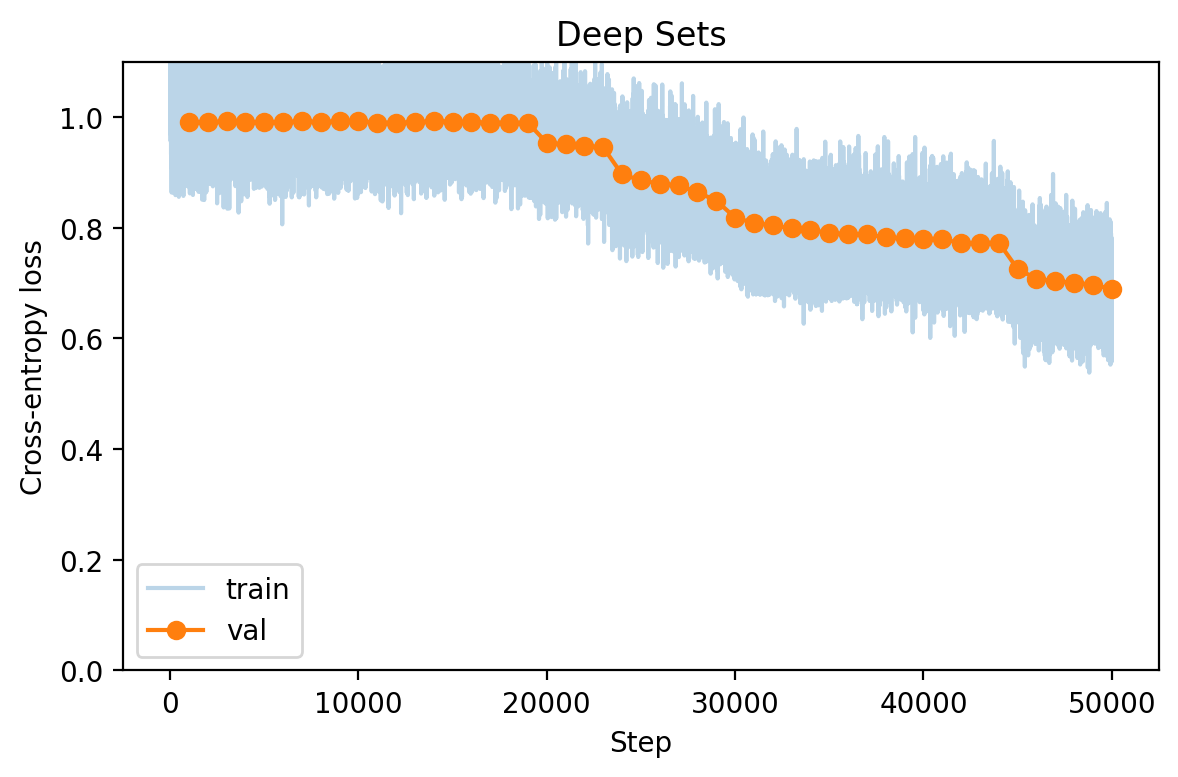

In [66]:
plot_training('Deep Sets', ds_losses, ds_val)

In [67]:
pred_orig = jnp.argmax(forward_deepsets(ds_params, s_orig, r_orig), axis=-1)
pred_perm = jnp.argmax(forward_deepsets(ds_params, s_perm, r_perm), axis=-1)
changed = float(jnp.mean(pred_orig != pred_perm))
print(f"Deep Sets: {100 * changed:.2g}% of predictions changed after permuting card order")

Deep Sets: 0% of predictions changed after permuting card order


# Model 3: Set Transformer

The [Set Transformer](https://arxiv.org/abs/1810.00825) (Lee et al., 2019) extends Deep Sets by adding **self-attention** between set elements before pooling. This allows the model to capture **interactions between cards** — for example, noticing that two cards share the same suit (relevant for flushes) or that ranks form a consecutive sequence (relevant for straights).

## Multi-head self-attention (without position)

Each card attends to every other card using the same attention mechanism as in standard Transformers, but **without positional encoding** and **without causal masking**:

For each card $x_i$ in the input set $x$, we compute **query**, **key**, and **value** vectors:
$$
q_i = W^q x_i, \quad k_j = W^k x_j, \quad v_j = W^v x_j
$$

The **attention weight** of card $i$ to card $j$ is:
$$
w_{ij} = \text{softmax}_j\left(\frac{q_i \cdot k_j}{\sqrt{d_k}}\right)
$$

The output for card $i$ is a weighted sum of values: $z_i = \sum_j w_{ij} v_j$.

Altogether, the of the attention mechanism is:
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Each transformer block uses pre-norm (layer normalization before each sub-layer) with residual connections.

Permutation-invariance: There is no positional encoding and no causal mask (which we discuss for text transformers), and therefore the attention is **permutation-equivariant**: permuting the input cards produces the same permutation in the output. After mean-pooling over cards, the full model is **permutation-invariant**.

In [68]:
# Set Transformer hyperparameters
st_d_model = 32
st_n_heads = 4
st_n_layers = 2
st_d_ff = 84


def layer_norm(x, eps=1e-6):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.mean((x - mean) ** 2, axis=-1, keepdims=True)
    return (x - mean) / jnp.sqrt(var + eps)


def self_attention(x, W_q, W_k, W_v, W_o, n_heads):
    """
    x: (B, T, d_model) -> (B, T, d_model)
    No positional encoding, no causal mask.
    """
    B, T, d_model = x.shape
    d_head = d_model // n_heads

    Q = (x @ W_q).reshape(B, T, n_heads, d_head).transpose(0, 2, 1, 3)
    K = (x @ W_k).reshape(B, T, n_heads, d_head).transpose(0, 2, 1, 3)
    V = (x @ W_v).reshape(B, T, n_heads, d_head).transpose(0, 2, 1, 3)

    w = (Q @ K.transpose(0, 1, 3, 2)) / jnp.sqrt(d_head)  # (B, H, T, T)
    w = jax.nn.softmax(w, axis=-1)

    z = (w @ V).transpose(0, 2, 1, 3).reshape(B, T, d_model)
    return z @ W_o


def init_params_settransformer(key):
    keys = iter(jax.random.split(key, 50))
    scale = 0.02

    def W(shape):
        return jax.random.normal(next(keys), shape) * scale

    blocks = []
    for _ in range(st_n_layers):
        blocks.append({
            'W_q': W((st_d_model, st_d_model)),
            'W_k': W((st_d_model, st_d_model)),
            'W_v': W((st_d_model, st_d_model)),
            'W_o': W((st_d_model, st_d_model)),
            'W1':  W((st_d_model, st_d_ff)),
            'b1':  jnp.zeros(st_d_ff),
            'W2':  W((st_d_ff, st_d_model)),
            'b2':  jnp.zeros(st_d_model),
        })

    return {
        'suit_emb': W((4, d_suit)),
        'rank_emb': W((13, d_rank)),
        'proj':     W((d_card, st_d_model)),
        'blocks':   blocks,
        'head_W':   W((st_d_model, n_classes)),
        'head_b':   jnp.zeros(n_classes),
    }


def forward_settransformer(params, suits, ranks):
    """suits, ranks: (B, 5) int -> logits: (B, n_classes)"""
    x = embed_cards(params, suits, ranks)      # (B, 5, d_card)
    x = x @ params['proj']                     # (B, 5, d_model)

    for blk in params['blocks']:
        # Pre-norm self-attention + residual
        x_norm = layer_norm(x)
        attn = self_attention(x_norm, blk['W_q'], blk['W_k'], blk['W_v'], blk['W_o'], st_n_heads)
        x = x + attn # residual connection
        # Pre-norm FFN + residual
        x_norm = layer_norm(x)
        h = jax.nn.relu(x_norm @ blk['W1'] + blk['b1'])
        x = x + h @ blk['W2'] + blk['b2']

    x = layer_norm(x)
    x = x.mean(axis=1) # mean pool over set: (B, d_model)
    return x @ params['head_W'] + params['head_b']

In [69]:
%%time
key, subkey = jax.random.split(key)
st_params, st_losses, st_val = train('Set Transformer', init_params_settransformer, forward_settransformer, subkey)

Set Transformer: 20,010 parameters
  step  1000 | train=0.3075 | val=0.2356
  step  2000 | train=0.0946 | val=0.0580
  step  3000 | train=0.0523 | val=0.0533
  step  4000 | train=0.0116 | val=0.0297
  step  5000 | train=0.0747 | val=0.0618
  step  6000 | train=0.0098 | val=0.0179
  step  7000 | train=0.0468 | val=0.0163
  step  8000 | train=0.0278 | val=0.0156
  step  9000 | train=0.0026 | val=0.0145
  step 10000 | train=0.0124 | val=0.0181
  step 11000 | train=0.0019 | val=0.0148
  step 12000 | train=0.0503 | val=0.0637
  step 13000 | train=0.0242 | val=0.0146
  step 14000 | train=0.0235 | val=0.0158
  step 15000 | train=0.0034 | val=0.0143
  step 16000 | train=0.0029 | val=0.0152
  step 17000 | train=0.0240 | val=0.0143
  step 18000 | train=0.0239 | val=0.0146
  step 19000 | train=0.0020 | val=0.0143
  step 20000 | train=0.0024 | val=0.0141
  step 21000 | train=0.0443 | val=0.0142
  step 22000 | train=0.0027 | val=0.0143
  step 23000 | train=0.0287 | val=0.0170
  step 24000 | train=0

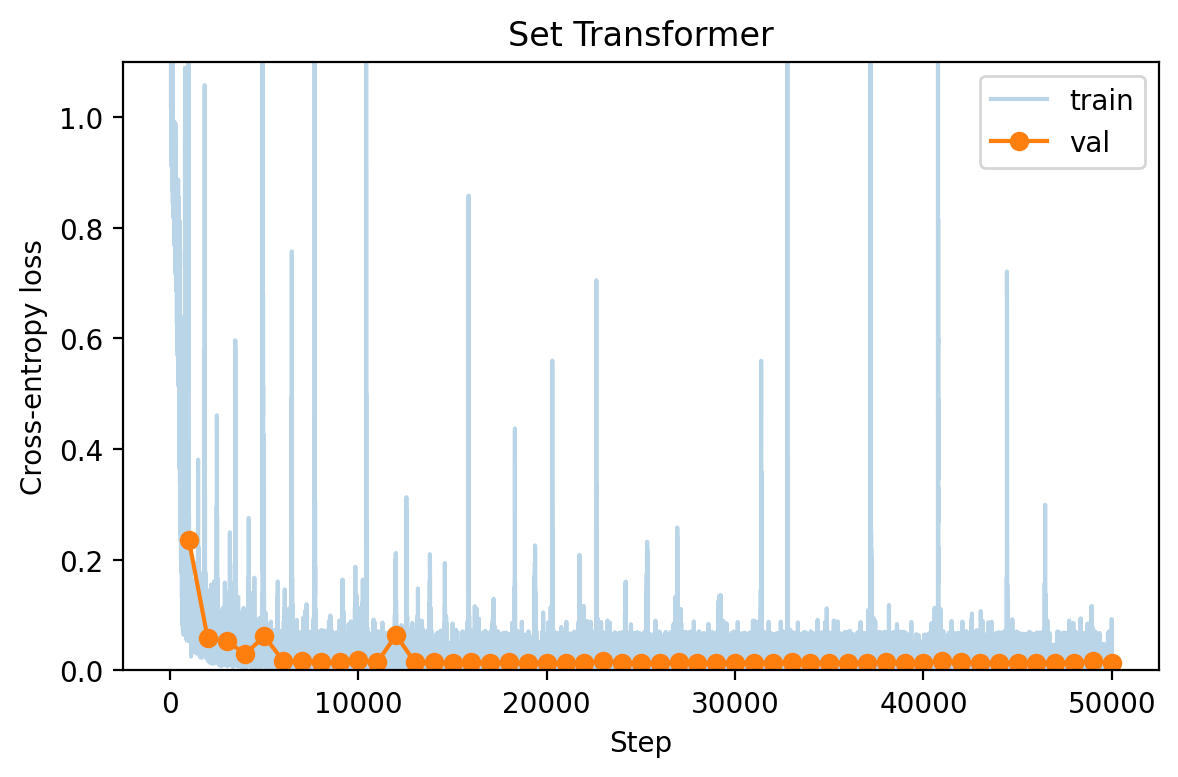

In [70]:
plot_training('Set Transformer', st_losses, st_val)

In [71]:
pred_orig = jnp.argmax(forward_settransformer(st_params, s_orig, r_orig), axis=-1)
pred_perm = jnp.argmax(forward_settransformer(st_params, s_perm, r_perm), axis=-1)
changed = float(jnp.mean(pred_orig != pred_perm))
print(f"Set Transformer: {100 * changed:.2g}% of predictions changed after permuting card order")

Set Transformer: 0% of predictions changed after permuting card order


# Comparison

We compare all three models on the same train/val/test split: parameter count, training dynamics, and test accuracy.

In [72]:
results = []
for name, params, forward_fn in [('Flattened FFN', ffn_params, forward_ffn),
                                 ('Deep Sets', ds_params, forward_deepsets),
                                 ('Set Transformer', st_params, forward_settransformer)]:
    n_p = count_params(params)
    train_acc = accuracy(params, forward_fn, train_suits[:10000], train_ranks[:10000], train_labels[:10000])
    val_acc = accuracy(params, forward_fn, val_suits, val_ranks, val_labels)
    test_acc = accuracy(params, forward_fn, test_suits, test_ranks, test_labels)
    results.append((name, n_p, train_acc, val_acc, test_acc))

print(f"{'Model':<20s} {'Params':>8s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 55)
for name, n_p, tr, va, te in results:
    print(f"{name:<20s} {n_p:>8,d} {100 * tr:>7.1f}% {100 * va:>7.1f}% {100 * te:>7.1f}%")

Model                  Params    Train      Val     Test
-------------------------------------------------------
Flattened FFN          20,150    99.5%    99.6%    99.5%
Deep Sets              20,152    69.5%    69.8%    69.5%
Set Transformer        20,010    99.8%    99.8%    99.8%


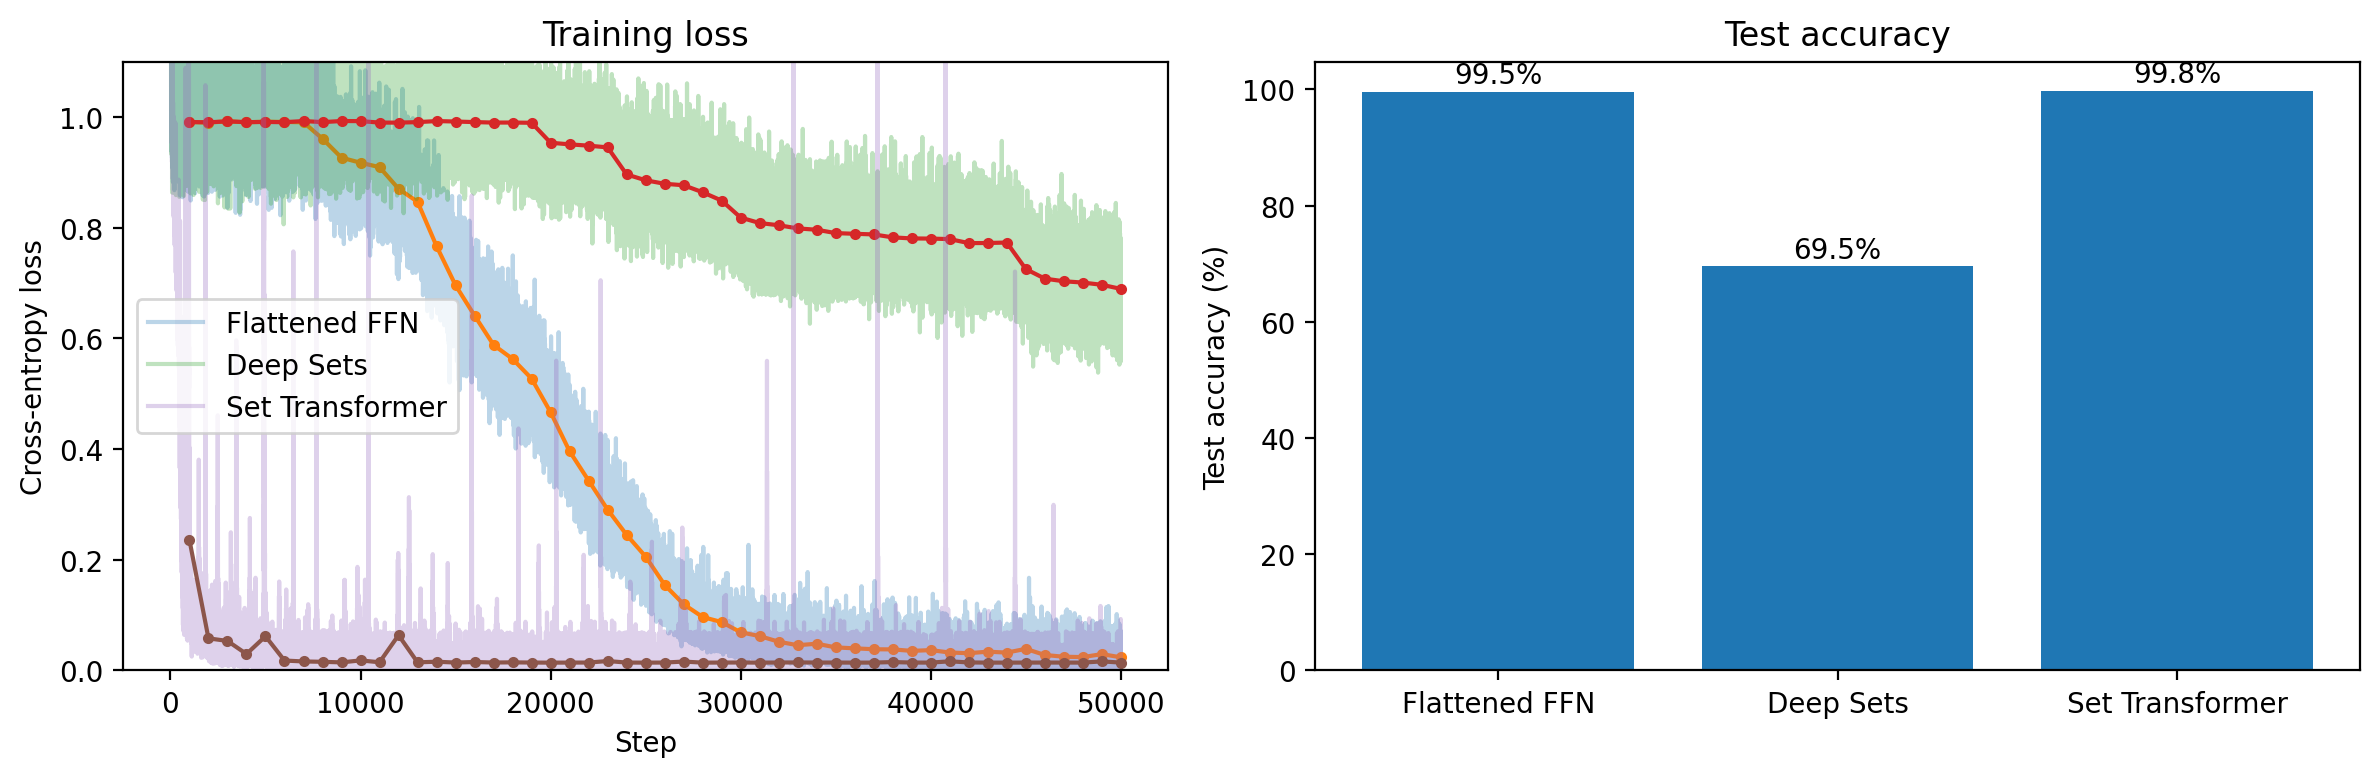

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training loss curves
for name, losses, val_log in [
    ('Flattened FFN', ffn_losses, ffn_val),
    ('Deep Sets', ds_losses, ds_val),
    ('Set Transformer', st_losses, st_val),
]:
    axes[0].plot(losses, alpha=0.3, label=name)
    if val_log:
        vs, vl = zip(*val_log)
        axes[0].plot(vs, vl, 'o-', markersize=3)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend() 
axes[0].set_title('Training loss')
axes[0].set_ylim(0, 1.1)

# Test accuracy bars
names = [r[0] for r in results]
test_accs = [100 * r[4] for r in results]
bars = axes[1].bar(names, test_accs)
axes[1].set_ylabel('Test accuracy (%)')
axes[1].set_title('Test accuracy')
for bar, acc in zip(bars, test_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout(); plt.show()

## Discussion

### What each architecture buys us

| Property | Flattened FFN | Deep Sets | Set Transformer |
|----------|:---:|:---:|:---:|
| Permutation invariant | ✗ | ✓ | ✓ |
| Variable-size input | ✗ | ✓ | ✓ |
| Inter-element interactions before pooling | ✗ | ✗ | ✓ |

- **Flattened FFN** is a useful baseline but has the wrong symmetry for sets. It must learn approximate invariance from data, wasting capacity. It also cannot generalise to different set sizes.

- **Deep Sets** provides the simplest correct symmetry for unordered inputs. For poker hands, where the class depends on counting how many cards share a rank or suit, sum pooling is a natural fit — it directly computes aggregate statistics. The theoretical result of Zaheer et al. guarantees that this architecture can represent *any* permutation-invariant function.

- **Set Transformer** adds self-attention before pooling, enabling content-dependent inter-card interactions. For example, attention can directly compare whether two cards share a suit (for flush detection) or have consecutive ranks (for straight detection), before the information is pooled into a single vector.

### Bridge to sequence models

In this notebook, the input is a **set** (unordered), so:
- No positional encoding is needed
- No causal masking is needed
- Permutation invariance is desired

In sequence models, the input is a **sequence** (ordered), so:
- **Positional encoding** injects order information (learned embeddings, or RoPE)
- **Causal masking** prevents attending to future tokens
- The model should be **permutation-sensitive** — "cat sat on mat" ≠ "mat sat on cat"

The attention mechanism is the same in both cases. The difference is entirely in what structural assumptions we add on top of it.

## References

1. **Zaheer et al. (2017)** Deep Sets. *NeurIPS*. [arXiv:1703.06114](https://arxiv.org/abs/1703.06114)
2. **Lee et al. (2019)** Set Transformer: A Framework for Attention-based Permutation-Invariant Input. *ICML*. [arXiv:1810.00825](https://arxiv.org/abs/1810.00825)
3. **Vaswani et al. (2017)** Attention Is All You Need. *NeurIPS*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
4. **Poker Hand dataset.** UCI Machine Learning Repository. [Link](https://archive.ics.uci.edu/dataset/158/poker+hand)

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)